In [8]:
from featuregraph.datasets import arc_agi
import featuregraph as fg
import numpy as np
import matplotlib.pyplot as plt

df = arc_agi("007bbfb7", split="training")

pair_type = 'train'
pair_index = 1

def reconstruct_grid(df, pair_type, pair_index, grid_role):
    mask = (df['pair_type'] == pair_type) & (df['pair_index'] == pair_index) & (df['grid_role'] == grid_role)
    cells = df[mask]

    return cells.pivot(
        index="row",
        columns="column",
        values="color",
    ).to_numpy()


input = reconstruct_grid(df, pair_type, pair_index, 'input')
output = reconstruct_grid(df, pair_type, pair_index, 'output')

colors, counts = np.unique(input, return_counts=True)
background_color = colors[np.argmax(counts)]

In [9]:
cells = fg.behaviors.spatial.partition_blocks(input, output)
blocks = fg.behaviors.spatial.compare_blocks(cells)

In [10]:
cells

,row,column,value,block_row,block_column,block_id,within_block_row,within_block_column,original_value,reflected_value,matches_original,matches_reflected,matches_background
0,0,0,4,0,0,0,0,0,4,4,True,True,False
1,0,1,0,0,0,0,0,1,0,0,True,True,True
2,0,2,4,0,0,0,0,2,4,4,True,True,False
3,0,3,0,0,1,1,0,0,4,4,False,False,True
4,0,4,0,0,1,1,0,1,0,0,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,8,4,4,2,1,7,2,1,4,4,True,True,False
77,8,5,0,2,1,7,2,2,0,0,True,True,True
78,8,6,0,2,2,8,2,0,0,0,True,True,True
79,8,7,0,2,2,8,2,1,4,4,False,False,True


In [11]:
blocks

,block_id,block_row,block_column,equals_original,equals_reflected,equals_background,cell_count,instruction
0,0,0,0,True,True,False,9,copy
1,1,0,1,False,False,True,9,fill_background
2,2,0,2,True,True,False,9,copy
3,3,1,0,False,False,True,9,fill_background
4,4,1,1,False,False,True,9,fill_background
5,5,1,2,False,False,True,9,fill_background
6,6,2,0,False,False,True,9,fill_background
7,7,2,1,True,True,False,9,copy
8,8,2,2,False,False,True,9,fill_background


In [12]:
layout, operators = fg.behaviors.spatial.build_instruction_layout(blocks, background_color)
manual_output = fg.behaviors.spatial.block_compose(layout, input, operators)
match = fg.behaviors.spatial.exact_match(manual_output, output)

print('Exact match:', match)

Exact match: True


In [13]:
cells[cells['block_id'] == 1]

,row,column,value,block_row,block_column,block_id,within_block_row,within_block_column,original_value,reflected_value,matches_original,matches_reflected,matches_background
3,0,3,0,0,1,1,0,0,4,4,False,False,True
4,0,4,0,0,1,1,0,1,0,0,True,True,True
5,0,5,0,0,1,1,0,2,4,4,False,False,True
12,1,3,0,0,1,1,1,0,0,0,True,True,True
13,1,4,0,0,1,1,1,1,0,0,True,True,True
14,1,5,0,0,1,1,1,2,0,0,True,True,True
21,2,3,0,0,1,1,2,0,0,0,True,True,True
22,2,4,0,0,1,1,2,1,4,4,False,False,True
23,2,5,0,0,1,1,2,2,0,0,True,True,True


In [14]:
blocks

,block_id,block_row,block_column,equals_original,equals_reflected,equals_background,cell_count,instruction
0,0,0,0,True,True,False,9,copy
1,1,0,1,False,False,True,9,fill_background
2,2,0,2,True,True,False,9,copy
3,3,1,0,False,False,True,9,fill_background
4,4,1,1,False,False,True,9,fill_background
5,5,1,2,False,False,True,9,fill_background
6,6,2,0,False,False,True,9,fill_background
7,7,2,1,True,True,False,9,copy
8,8,2,2,False,False,True,9,fill_background


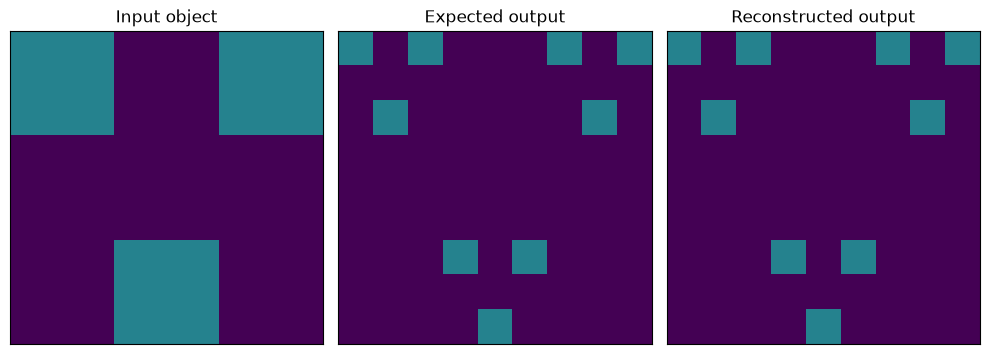

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(input, vmin=0, vmax=9)
axes[0].set_title("Input object")

axes[1].imshow(output, vmin=0, vmax=9)
axes[1].set_title("Expected output")

axes[2].imshow(manual_output, vmin=0, vmax=9)
axes[2].set_title("Reconstructed output")

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()